In [7]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from skimage import measure
import xarray as xr


dirpath_base = Path('D:\\WORK\\Salvador\\repo\\model_tuner\\test_data\\a1_ou_unconn\\scott_2025_03_13')
fpath_in = dirpath_base / 'OUmapping_master_compat.pkl'

dirpath_out = dirpath_base / 'plots'
dirpath_out.mkdir(exist_ok=True)

with open(fpath_in, 'rb') as file:
    data = pickle.load(file)

pop_names = list(data['rate'].keys())

pop_name = pop_names[0]

R = data['rate'][pop_name]

# Coordinates
ouamp_vec = R.columns.values * 100
oustd_vec = R.index.values * 100

# Interpolated contour coords
ouamp_vec_ = ouamp_vec
oustd_vec_ = (ouamp_vec_ * 0.4).clip(oustd_vec.min(), oustd_vec.max())

X = xr.DataArray(
    R.values,
    dims=('oustd', 'ouamp'),
    coords=[('oustd', oustd_vec), ('ouamp', ouamp_vec)]
)
Q = {
    'ouamp': xr.DataArray(ouamp_vec_, dims='points'),
    'oustd': xr.DataArray(oustd_vec_, dims='points'),
}
xx = X.interp(**Q, method='linear').values


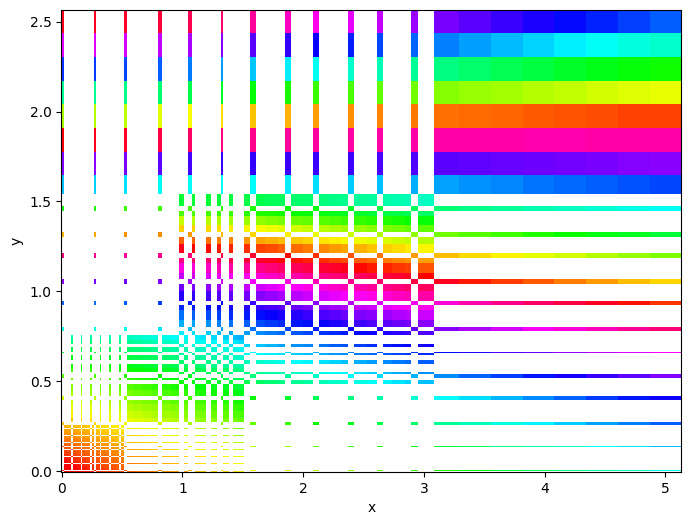

In [44]:
import matplotlib.colors as mcolors

def get_wrapped_cmap(base_cmap='hsv', cycles=3):
    base = plt.get_cmap(base_cmap)
    colors = base(np.linspace(0, 1, 256))
    repeated = np.tile(colors, (cycles, 1))
    return mcolors.ListedColormap(repeated)

def plot_xr(X, vmin=None, vmax=None, cmap='viridis'):

    x = X.coords['ouamp'].values
    y = X.coords['oustd'].values
    z = X.values.T

    vmin = vmin or np.nanmin(z)
    vmax = vmax or np.nanmax(z)

    # Create 2D meshgrid of the coordinates
    xx, yy = np.meshgrid(x, y)

    if cmap == 'wrapped':
        cmap = get_wrapped_cmap()

    ax  = plt.gca()
    ax.pcolormesh(xx, yy, z, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.figure(figsize=(8, 6))
plot_xr(X, cmap='wrapped')

In [30]:
import numpy as np
import xarray as xr
from scipy.interpolate import griddata

# Suppose X has dims ('y','x') and coordinates X['y'] and X['x']
# 1. Flatten out the valid points
mask = ~np.isnan(X.values)
y_coords_2d, x_coords_2d = np.meshgrid(X['oustd'], X['ouamp'], indexing='ij')
y_valid = y_coords_2d[mask]
x_valid = x_coords_2d[mask]

values_valid = X.values[mask]

#np.sum(np.isnan(values_valid))
print(f'Size (total): {X.values.size}')
print(f'Size (valid): {np.sum(~np.isnan(X.values))}')
print(f'Sum (mask): {np.sum(mask.ravel())}')
print(f'Size (values_valid): {values_valid.size}')
mask.shape

Size (total): 6241
Size (valid): 1599
Sum (mask): 1599
Size (values_valid): 1599


(79, 79)

In [65]:
from typing import Tuple

def extract_2d_points_from_xr(
        Z: xr.DataArray,
        drop_nan: bool = True
        ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Extract coords and values from a 2D xarray
    if X.ndim != 2:
        raise ValueError('Input xarray must be 2D')
    mask = ~np.isnan(Z.values)
    y, x = Z[Z.dims[0]], Z[Z.dims[1]]
    yy, xx = np.meshgrid(y, x, indexing='ij')
    zz = Z.values
    if drop_nan:
        yy = yy[mask]
        xx = xx[mask]
        zz = zz[mask]
    return yy, xx, zz

y_valid, x_valid, values_valid = extract_2d_points_from_xr(X)

In [66]:
def fill_2d_xr(
        Z: xr.DataArray,
        method: str = 'cubic'
        ) -> xr.DataArray:
    # Fill 2D xarray using SciPy's griddata
    yy, xx, zz = extract_2d_points_from_xr(Z, drop_nan=True)
    yy_, xx_, _ = extract_2d_points_from_xr(Z, drop_nan=False)
    zz_ = griddata(
        (yy, xx),        # known coordinates
        zz,              # known values
        (yy_, xx_),      # target grid
        method=method
    )
    return xr.DataArray(zz_, coords=Z.coords, dims=Z.dims)

X_filled = fill_2d_xr(X)

In [ ]:
"""
# 2. Create the full grid and apply SciPy’s cubic interpolation
y_grid, x_grid = np.meshgrid(X['oustd'], X['ouamp'], indexing='ij')
filled = griddata(
    (y_valid, x_valid),        # known coordinates
    values_valid,              # known values
    (y_grid, x_grid),          # target grid
    method='cubic'
)

# 3. Convert interpolated result back to a XtaArray
X_filled = xr.DataArray(
    filled,
    coords=X.coords,          # reuse original coords
    dims=X.dims
)
"""

In [67]:
X_masked = xr.where(X.isnull(), np.nan, X_filled)

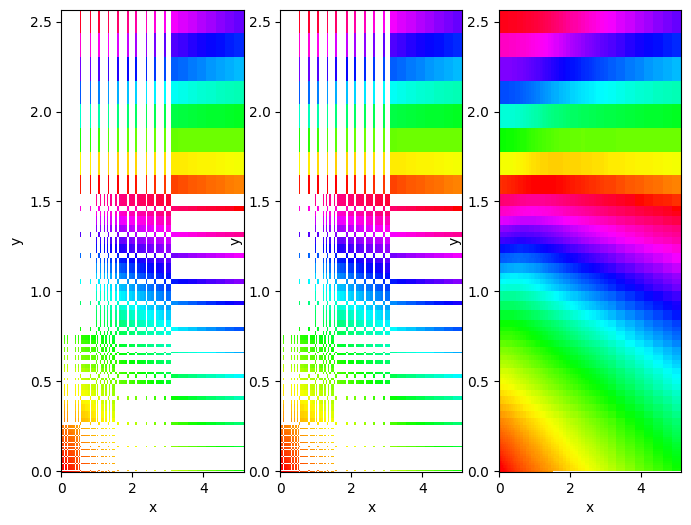

In [68]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 3, 1)
vmin = np.nanmin(X.values)
vmax = np.nanmax(X.values)
cmap = get_wrapped_cmap(cycles=2)
#cmap = 'viridis'
plot_xr(X, vmin=vmin, vmax=vmax, cmap=cmap)
plt.subplot(1, 3, 2)
plot_xr(X_masked, vmin=vmin, vmax=vmax, cmap=cmap)
plt.subplot(1, 3, 3)
plot_xr(X_filled, vmin=vmin, vmax=vmax, cmap=cmap)